In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from inputs_for_plots import *

In [2]:
def prepare_error_dataframe(ols_est, errors_list, column_names):
    """Creates a DataFrame with all error values in a long format."""
    df_list = [pd.DataFrame(np.abs(ols_est), columns=["Biased OLS"])]
    for errors, col_name in zip(errors_list, column_names):
        df_list.append(pd.DataFrame(errors["error"], columns=[col_name]))
    return pd.concat(df_list, axis=1)


## Plot increase in confounding

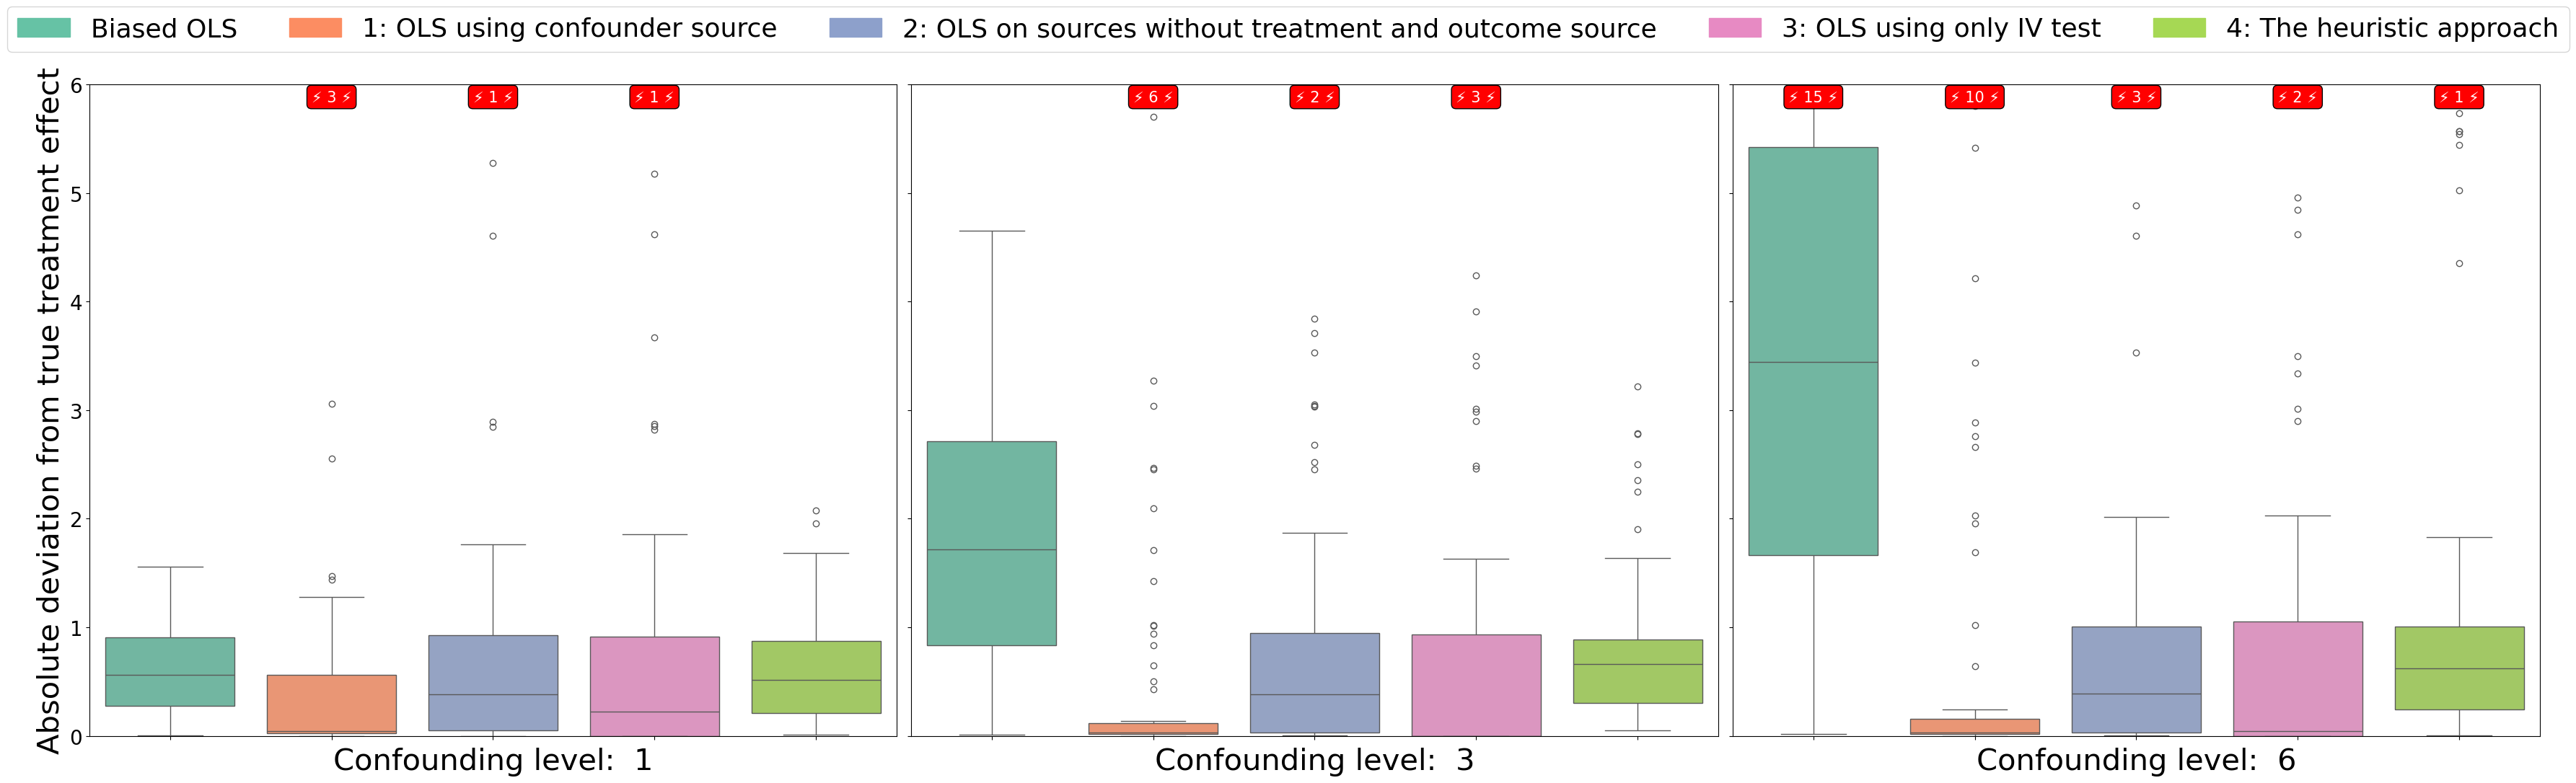

In [3]:

def main_plot(confounder_levels):
    """Generates plots for different confounder levels."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(35, 10), sharey=True)
    
    
    for i, level in enumerate(confounder_levels):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_confounding_levels/data/", name=f"true_mixing_large_conf_{level}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_confounding_levels/data/", name=f"data_obs_large_conf_{level}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
        
        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_cn_{level}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_cn_{level}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_cn_{level}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_cn_{level}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

      
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense ], ["1: OLS using confounder source", "2: OLS on sources without treatment and outcome source"
                                                                                                                        , "3: OLS using only IV test", "4: The heuristic approach"])
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[level] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], level, "Confounding level", y_lim=6)
    
    # add one legend for all plots
    add_one_legend(fig, err, palette, 26 )
    plt.tight_layout()
    plt.show()
    return method_summary

# Example usage
confounder_levels = [1, 3, 6]
method_summary = main_plot(confounder_levels)


In [4]:
print_method_summary(method_summary)

Level 1
+-------+--------------+----------------------------------+----------------------------------------------------------+-----------------------------+-----------------------------+
|       |   Biased OLS |   1: OLS using confounder source |   2: OLS on sources without treatment and outcome source |   3: OLS using only IV test |   4: The heuristic approach |
|-------+--------------+----------------------------------+----------------------------------------------------------+-----------------------------+-----------------------------|
| RMSE  |         0.69 |                             1.83 |                                                     1.63 |                        1.66 |                        0.74 |
| MAE   |         0.59 |                             0.61 |                                                     0.77 |                        0.76 |                        0.6  |
| STD   |         0.69 |                             1.82 |                                      

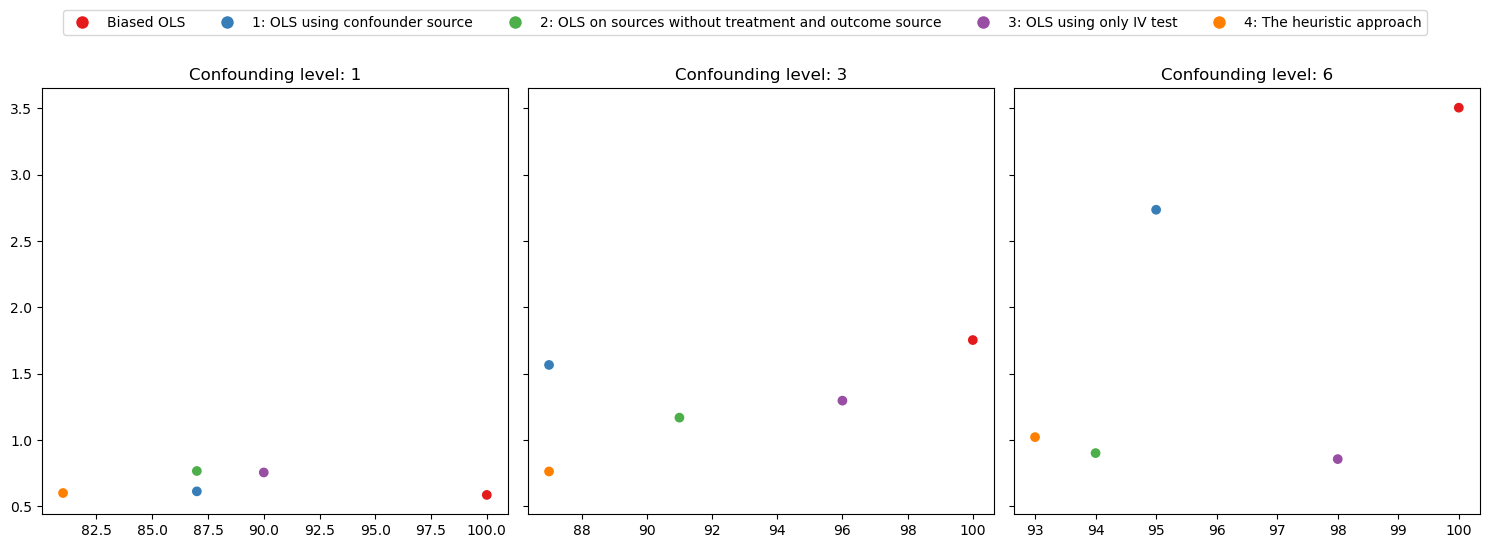

In [5]:
plot_cases_vs_performance(method_summary, "mae", "Confounding level")

## Plot different number of covariates

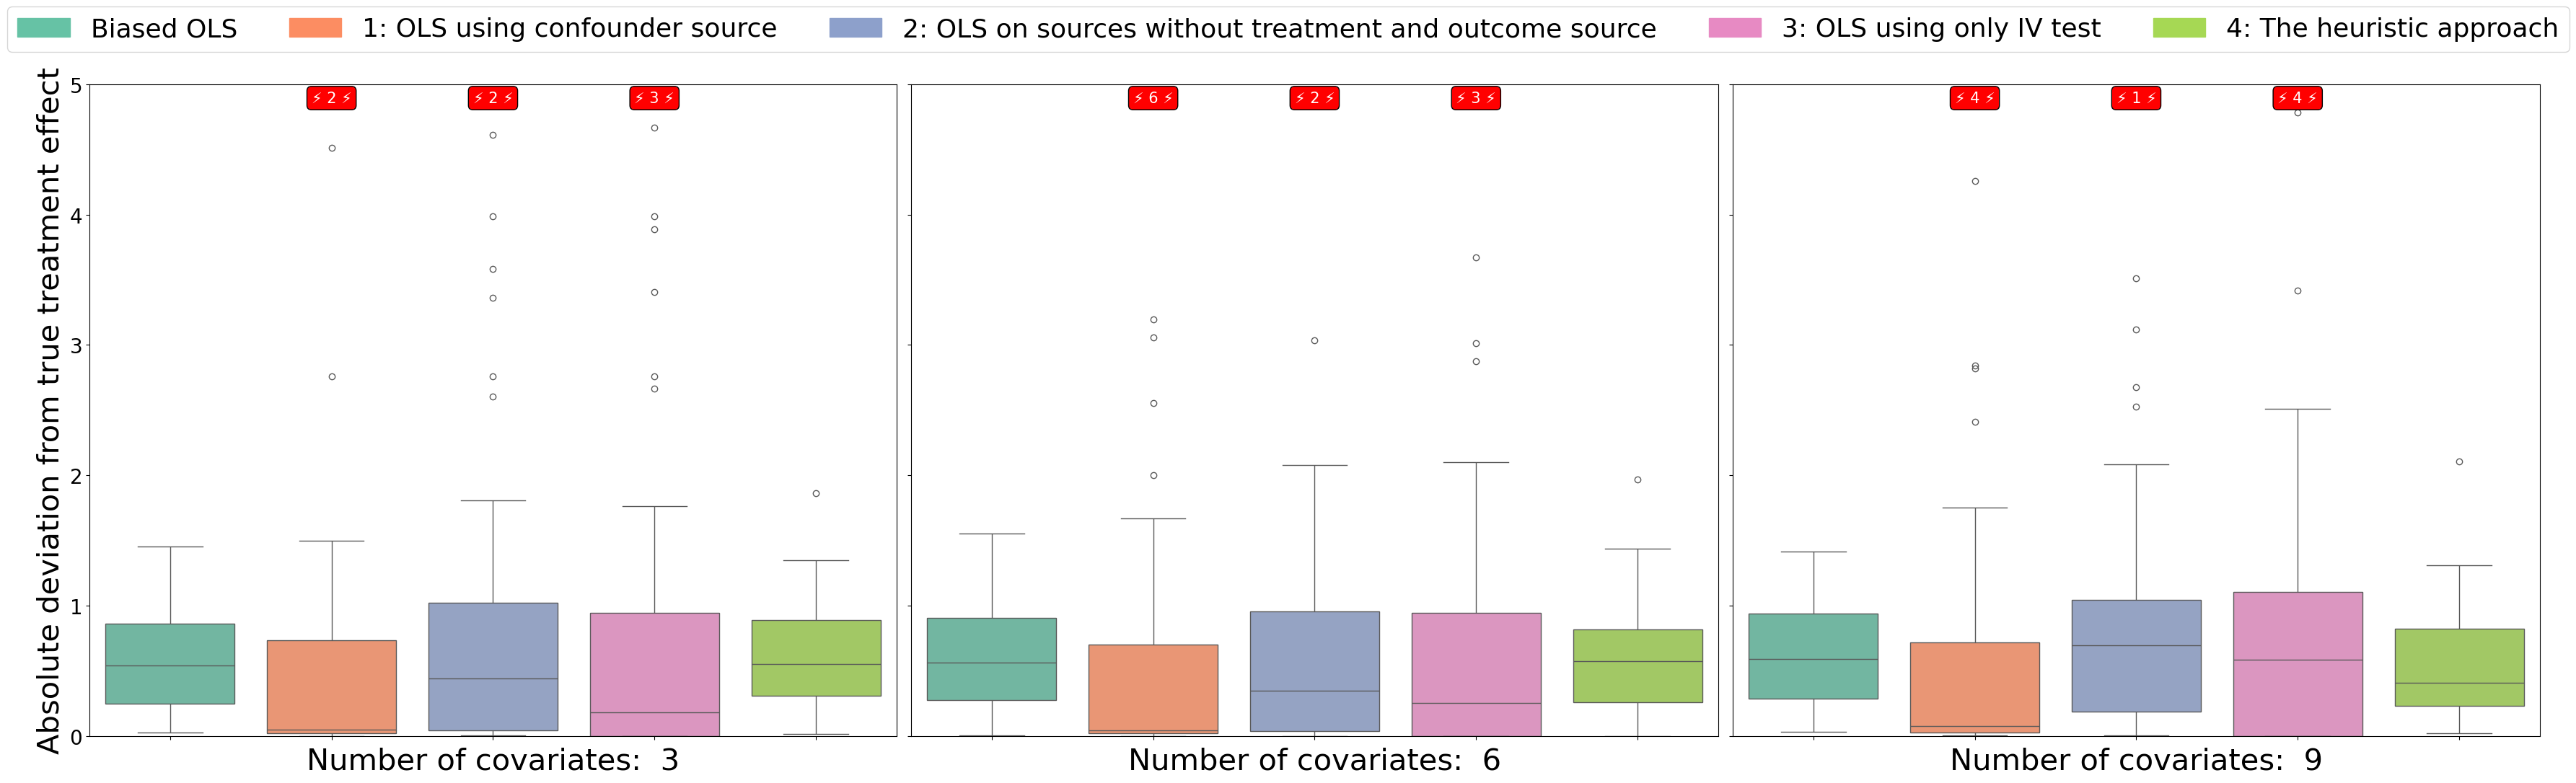

In [6]:
def main_plot(number_of_covariates):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(35, 10), sharey=True)
    
    for i, covs in enumerate(number_of_covariates):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_numbers_of_covariates/data/", name=f"true_mixing_covs_{covs}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_numbers_of_covariates/data/", name=f"data_obs_covs_{covs}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)


        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_number_of_covs_{covs}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_number_of_covs_{covs}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_number_of_covs_{covs}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_number_of_covs_{covs}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        


        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense ], ["1: OLS using confounder source", "2: OLS on sources without treatment and outcome source"
                                                                                                                        , "3: OLS using only IV test", "4: The heuristic approach"])
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[covs] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], covs, "Number of covariates", y_lim=5)
        
    
    add_one_legend(fig, err, palette, 26 )
    plt.tight_layout()
    plt.show()
    return method_summary

# Example usage
number_of_covariates = [3, 6, 9]
method_summary = main_plot(number_of_covariates)




In [7]:
print_method_summary(method_summary)

Level 3
+-------+--------------+----------------------------------+----------------------------------------------------------+-----------------------------+-----------------------------+
|       |   Biased OLS |   1: OLS using confounder source |   2: OLS on sources without treatment and outcome source |   3: OLS using only IV test |   4: The heuristic approach |
|-------+--------------+----------------------------------+----------------------------------------------------------+-----------------------------+-----------------------------|
| RMSE  |         0.69 |                             3.54 |                                                     2.72 |                        2.98 |                        0.71 |
| MAE   |         0.57 |                             0.89 |                                                     1.05 |                        1.1  |                        0.6  |
| STD   |         0.69 |                             3.52 |                                      

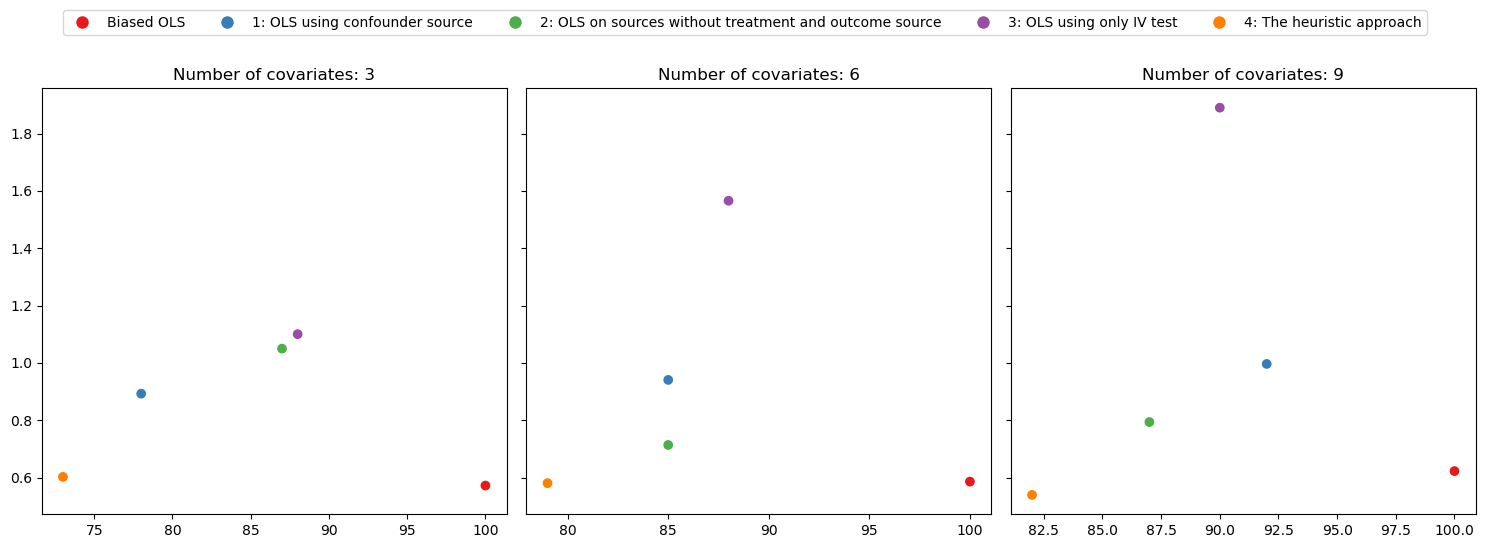

In [8]:
plot_cases_vs_performance(method_summary, "mae", "Number of covariates")

## Plot different sample sizes

{'Biased OLS': 100, '1: OLS using confounder source': 85, '2: OLS on sources without treatment and outcome source': 88, '3: OLS using only IV test': 90, '4: The heuristic approach': 78}
{'Biased OLS': 100, '1: OLS using confounder source': 67, '2: OLS on sources without treatment and outcome source': 96, '3: OLS using only IV test': 83, '4: The heuristic approach': 89}
{'Biased OLS': 100, '1: OLS using confounder source': 65, '2: OLS on sources without treatment and outcome source': 99, '3: OLS using only IV test': 83, '4: The heuristic approach': 93}


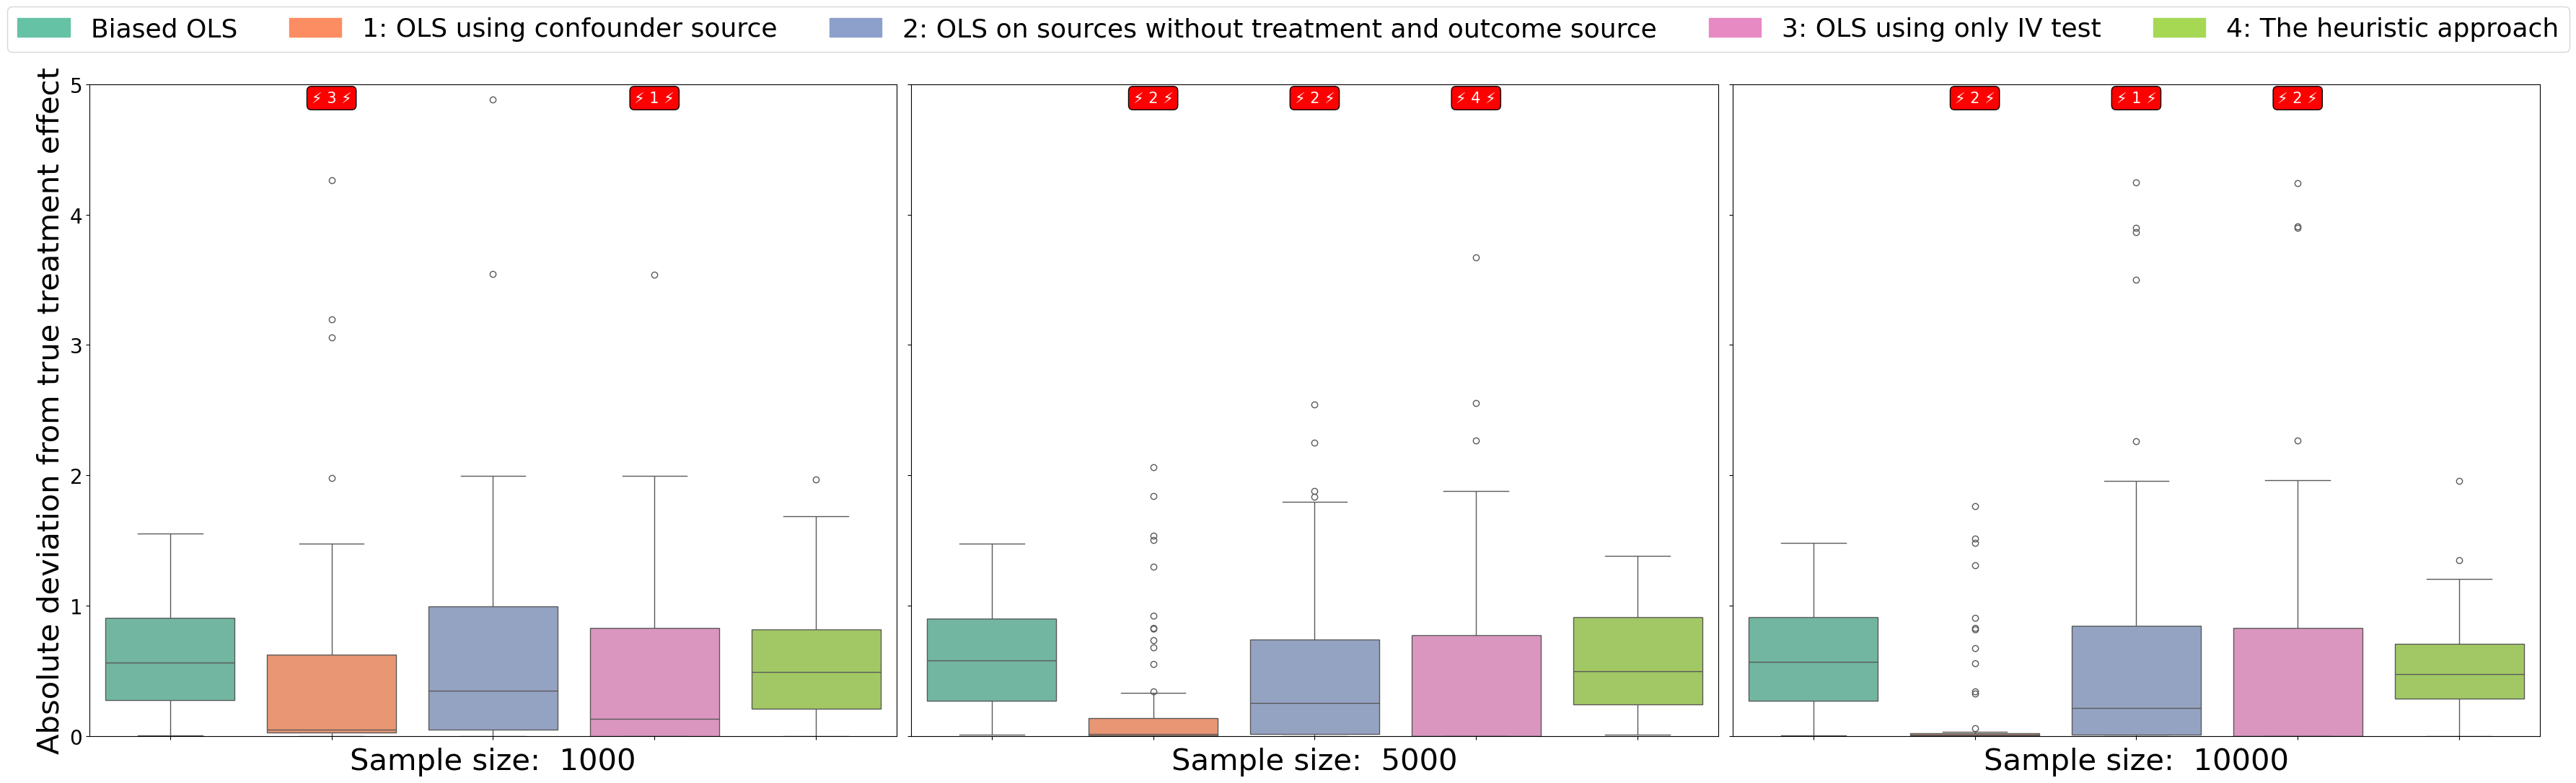

In [9]:
def main_plot(ns):
    """Generates plots for different number of sample sizes."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(35, 10), sharey=True)
    
    for i, n in enumerate(ns):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/differen_sample_sizes/data/", name=f"true_mixing_n:{n}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/differen_sample_sizes/data/", name=f"data_obs_n:{n}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)


        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_n:{n}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_n:{n}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_n:{n}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_n:{n}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense ], ["1: OLS using confounder source", "2: OLS on sources without treatment and outcome source"
                                                                                                                        , "3: OLS using only IV test", "4: The heuristic approach"])  
         
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        print(cases) 
        method_summary[n] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], n,"Sample size", y_lim=5)
        
        
    
    add_one_legend(fig, err, palette, 26 )
    plt.tight_layout()
    plt.show()
    return method_summary

# Example usage
ns = [1000, 5000, 10000]
method_summary = main_plot(ns)




In [10]:
print_method_summary(method_summary)

Level 1000
+-------+--------------+----------------------------------+----------------------------------------------------------+-----------------------------+-----------------------------+
|       |   Biased OLS |   1: OLS using confounder source |   2: OLS on sources without treatment and outcome source |   3: OLS using only IV test |   4: The heuristic approach |
|-------+--------------+----------------------------------+----------------------------------------------------------+-----------------------------+-----------------------------|
| RMSE  |         0.69 |                             1.45 |                                                     1    |                        1.16 |                        0.69 |
| MAE   |         0.59 |                             0.61 |                                                     0.63 |                        0.59 |                        0.56 |
| STD   |         0.69 |                             1.45 |                                   

In [11]:
errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_n:{5000}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_n:{5000}.csv", "iv_only_effect", "true_treatment_effect")

print(errors_confounder["RMSE"])
print(errors_iv_only["RMSE"])

print(errors_confounder["error"].median())
print(errors_iv_only["error"].median())

2.2082063573472097
36.66059915397965
0.013249374893629984
1.099120794378905e-14


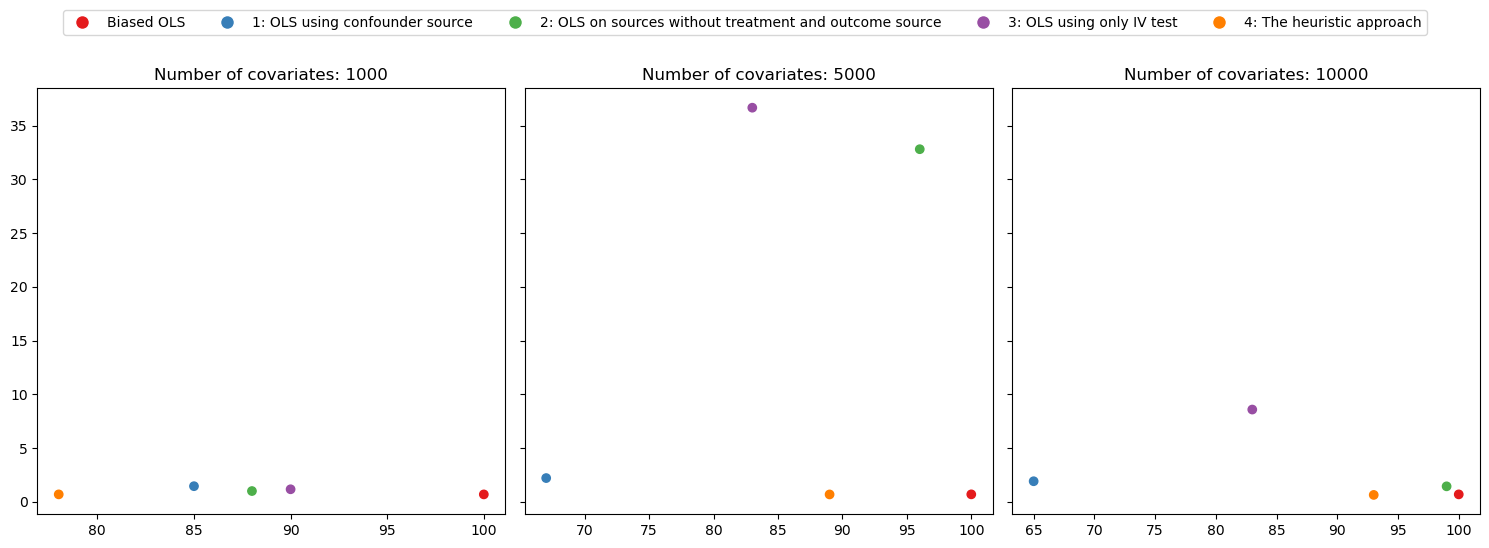

In [12]:
plot_cases_vs_performance(method_summary, "rmse", "Number of covariates")

 # Plot bounded treatment effect

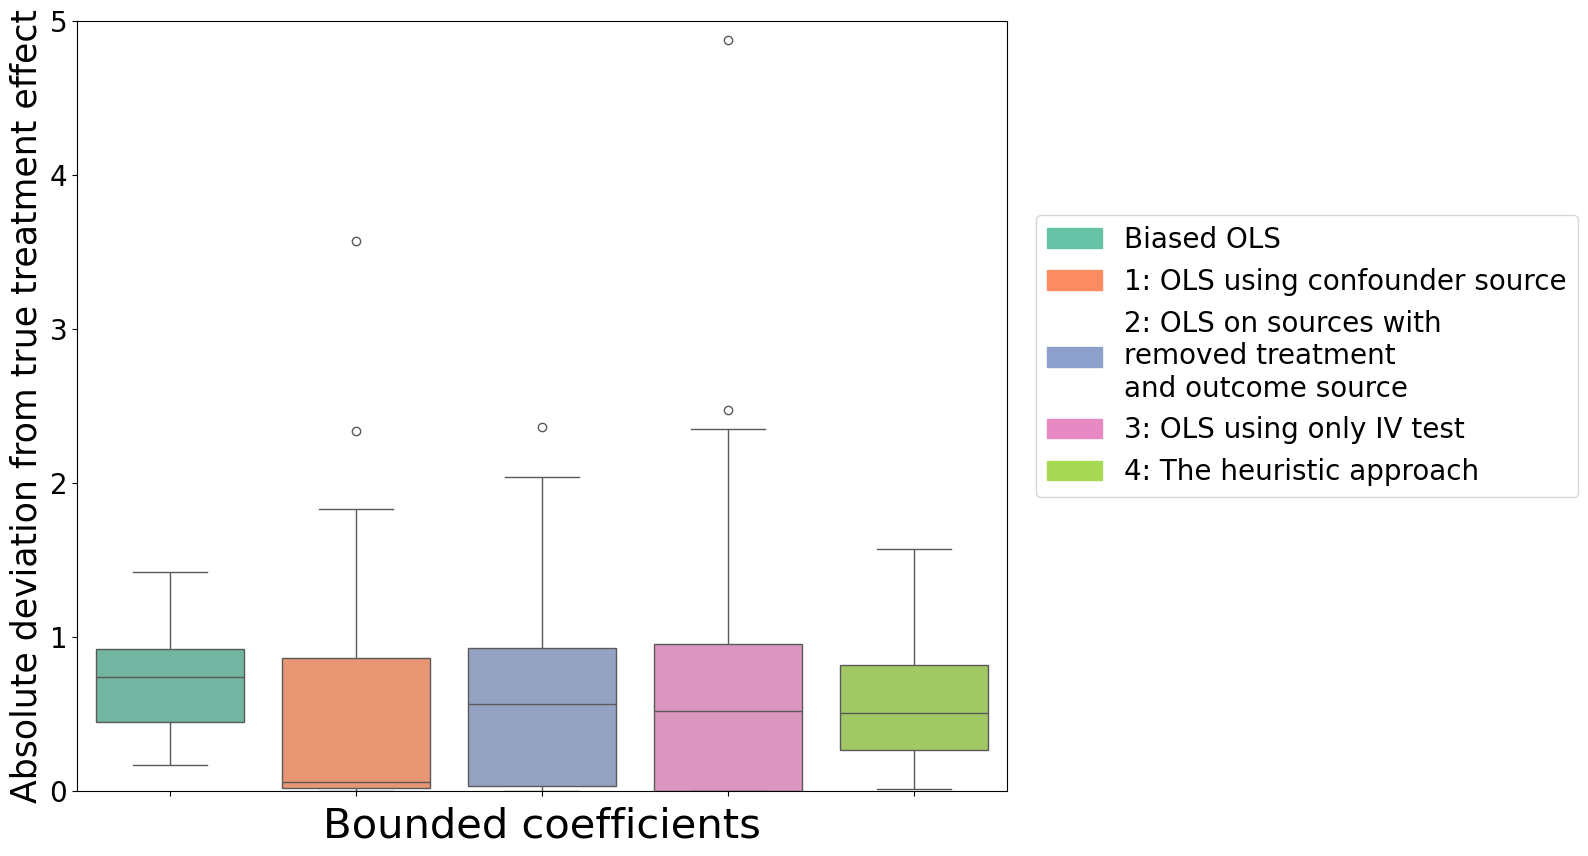

Bounded treatment effect
                                                    RMSE   MAE   STD  Cases
Biased OLS                                          0.78  0.71  0.78    100
1: OLS using confounder source                      0.78  0.47  0.78     93
2: OLS on sources with \nremoved treatment \nan...  0.83  0.61  0.82     91
3: OLS using only IV test                           0.96  0.61  0.96     93
4: The heuristic approach                           0.67  0.57  0.67     86


In [13]:
def plot_errors_bounded(err, rmse, mae, std,ax, y_lim = 5):
    """Creates boxplots and adds legend with RMSE, MAE, and STD."""
    df_long = err.melt(var_name="variable", value_name="value").dropna()
    palette = sns.color_palette("Set2", n_colors=len(df_long["variable"].unique()))
    boxplot = sns.boxplot(data=df_long, y="value", x="variable", hue="variable", ax=ax, palette=palette, legend=False)
    
    ax.set_xlabel(f"Bounded coefficients", fontsize=30)
    ax.set_ylabel("Absolute deviation from true treatment effect", fontsize=25)

    ax.set_xticklabels([])  
    ax.tick_params(axis='both', which='major', labelsize=20)

    ax.set_ylim((0, y_lim))


    outlier_counts = df_long[df_long["value"] > y_lim].groupby("variable").size()


    positions = ax.get_xticks()  
    for pos, variable in zip(positions, df_long['variable'].unique()):
        count = outlier_counts.get(variable, 0)  
        

        if count > 0:

            ax.text(
                pos, y_lim -.05, f"⚡ {count} ⚡", 
                ha='center', va='top', 
                fontsize=15, color="white", 
                bbox=dict(facecolor='red', edgecolor='black', boxstyle='round,pad=0.3')
            )
            
    return palette

true_treatment = get_true_treatment_effect(path="data_generation/bounded_treatment_effect/data/", name="true_mixing_init_flipp_")
ols_est = calculate_ols_estimate(path=f"data_generation/bounded_treatment_effect/data/", name= "data_obs_init_flipp_")
ols_est = np.array(ols_est) - np.array(true_treatment)




errors_confounder = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_bounded_treatment.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
errors_7_sources = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_bounded_treatment.csv", "estimated_treatment_on_sources", "true_treatment_effect")
errors_nonsense = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_bounded_treatment.csv", "mistaken_scheme", "true_treatment_effect")
errors_iv_only = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_bounded.csv", "iv_only_effect", "true_treatment_effect")

rmse, mae, std = [], [], []
gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
gather_statistics(errors_confounder, rmse, mae, std)
gather_statistics(errors_7_sources, rmse, mae, std)
gather_statistics(errors_iv_only, rmse, mae, std)
gather_statistics(errors_nonsense, rmse, mae, std)


err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense, ], ["1: OLS using confounder source", "2: OLS on sources with \nremoved treatment \nand outcome source", 
                                                                                                                        "3: OLS using only IV test", "4: The heuristic approach"])
no_of_cases = {col: 100 - err[col].isna().sum() for col in err.columns}
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
palette = plot_errors_bounded(err, rmse, mae, std, ax)  
handles = [
        mpatches.Patch(color=palette[i], label=f"{err.columns[i]}")
        for i in range(len(err.columns))
    ]
    
fig.legend(handles=handles, loc="upper center", ncol=1, fontsize=20, bbox_to_anchor=(1.15, .7))
plt.show()

# print metric summary
print("Bounded treatment effect")
print(pd.DataFrame({"RMSE": rmse, "MAE": mae, "STD": std, "Cases": no_of_cases}, index=err.columns).round(2))

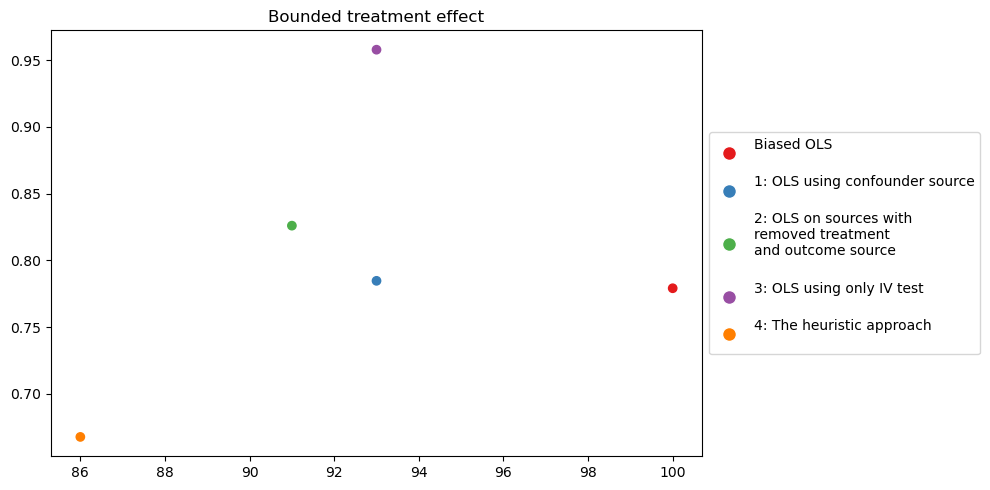

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharey=True)



methods = no_of_cases.keys()
cases = no_of_cases.values()
palette = sns.color_palette("Set1", len(methods))
ax.scatter(cases, rmse, c=palette, label=methods)

ax.set_title("Bounded treatment effect")    

legend_labels = list(methods)
legend_colors = palette[:len(legend_labels)]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in legend_colors]

# Add line breaks after each method in the legend
legend_labels = [label + '\n' for label in legend_labels]

# Position the legend to the left of the plot
ax.legend(handles, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

plt.tight_layout()
plt.show()
